# HW3: LLM-as-Judge for Recipe Bot Evaluation

**Goal**: Measure how well the bot follows dietary restrictions using an LLM judge, corrected for judge bias.

In [3]:
import json
import os
import re
import random
import warnings
import litellm
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from dotenv import load_dotenv
from IPython.display import display
import ipywidgets as widgets

warnings.filterwarnings('ignore', category=UserWarning, module='pydantic')
load_dotenv(dotenv_path='../../.env')

LABELED_PATH = Path('data/labeled_traces.jsonl')
MODEL_JUDGE = os.environ.get('MODEL_NAME_JUDGE', 'openai/gpt-4.1-mini')

with open(LABELED_PATH) as f:
    labeled = [json.loads(l) for l in f]

labels = Counter(t['label'] for t in labeled)
print(f'Total: {len(labeled)}  PASS: {labels["PASS"]}  FAIL: {labels["FAIL"]}')
print(f'Model: {MODEL_JUDGE}')

Total: 51  PASS: 42  FAIL: 9
Model: openai/gpt-4.1-mini


## Step 1: Train / Dev / Test Split
- **Train** (~15%): few-shot examples for judge prompt
- **Dev** (~40%): iteratively refine judge
- **Test** (~45%): final TPR/TNR measurement (touch only once)

In [4]:
random.seed(42)

passes_l = [t for t in labeled if t['label'] == 'PASS']
fails_l  = [t for t in labeled if t['label'] == 'FAIL']
random.shuffle(passes_l)
random.shuffle(fails_l)

def split(items, train_frac=0.22, dev_frac=0.33):
    n = len(items)
    n_train = round(n * train_frac)
    n_dev   = round(n * dev_frac)
    return items[:n_train], items[n_train:n_train+n_dev], items[n_train+n_dev:]

train_p, dev_p, test_p = split(passes_l)
train_f, dev_f, test_f = split(fails_l)

train = train_p + train_f
dev   = dev_p   + dev_f
test  = test_p  + test_f

random.shuffle(train); random.shuffle(dev); random.shuffle(test)

print(f'Train : {len(train):3d}  (PASS={len(train_p)}, FAIL={len(train_f)})')
print(f'Dev   : {len(dev):3d}  (PASS={len(dev_p)}, FAIL={len(dev_f)})')
print(f'Test  : {len(test):3d}  (PASS={len(test_p)}, FAIL={len(test_f)})')

Train :  11  (PASS=9, FAIL=2)
Dev   :  17  (PASS=14, FAIL=3)
Test  :  23  (PASS=19, FAIL=4)


## Step 2: Judge Infrastructure

In [5]:
import re

def run_judge(prompt_template, trace):
    prompt = prompt_template.format(
        dietary_restriction=trace['dietary_restriction'],
        query=trace['query'],
        response=trace['response'],
    )
    resp = litellm.completion(
        model=MODEL_JUDGE,
        messages=[{'role': 'user', 'content': prompt}],
        response_format={'type': 'json_object'},
    )
    result = json.loads(resp.choices[0].message.content)
    label_keys = ['label', 'verdict', 'decision', 'result', 'judgment', 'judgement']
    reasoning_keys = ['reasoning', 'reason', 'explanation', 'rationale']
    label = next((result[k] for k in label_keys if k in result), None)
    reasoning = next((result[k] for k in reasoning_keys if k in result), '')
    if label is None:
        matches = re.findall(r'\b(PASS|FAIL)\b', reasoning.upper())
        if matches:
            label = matches[-1]
        else:
            print(f'  [WARN] Could not extract label from: {result}')
            label = 'FAIL'
    return label.strip().upper(), reasoning


def evaluate(split_data, split_name, prompt_template):
    results = []
    out = widgets.Output()
    bar = widgets.IntProgress(value=0, min=0, max=len(split_data),
                              description=f'{split_name}:', bar_style='info',
                              layout=widgets.Layout(width='60%'))
    status_label = widgets.Label(value='')
    display(widgets.VBox([bar, status_label, out]))

    for i, trace in enumerate(split_data):
        judge_label, reasoning = run_judge(prompt_template, trace)
        human_label = trace['label']
        correct = judge_label == human_label
        results.append({**trace, 'judge_label': judge_label, 'judge_reasoning': reasoning, 'correct': correct})
        bar.value = i + 1
        icon = '✓' if correct else '✗'
        status_label.value = f'[{i+1}/{len(split_data)}] {icon} human={human_label} judge={judge_label}  ({trace["dietary_restriction"]})'
        if not correct:
            with out:
                print(f'  [{i+1:2d}] ✗ human={human_label} judge={judge_label}  {trace["dietary_restriction"]} | {trace["query"][:60]}')

    bar.bar_style = 'success'
    tp = sum(1 for r in results if r['label']=='PASS' and r['judge_label']=='PASS')
    fn = sum(1 for r in results if r['label']=='PASS' and r['judge_label']=='FAIL')
    tn = sum(1 for r in results if r['label']=='FAIL' and r['judge_label']=='FAIL')
    fp = sum(1 for r in results if r['label']=='FAIL' and r['judge_label']=='PASS')
    tpr = tp/(tp+fn) if (tp+fn)>0 else 0
    tnr = tn/(tn+fp) if (tn+fp)>0 else 0
    acc = sum(r['correct'] for r in results)/len(results)
    with out:
        print(f'\n=== {split_name} Results ===')
        print(f'Accuracy : {acc:.2%}')
        print(f'TPR      : {tpr:.2%}  (judge correctly identifies PASS)')
        print(f'TNR      : {tnr:.2%}  (judge correctly identifies FAIL)')
        print(f'Confusion: TP={tp} FN={fn} TN={tn} FP={fp}')
    return results, tpr, tnr


def show_errors(results, version):
    fps = [r for r in results if r['label']=='FAIL' and r['judge_label']=='PASS']
    fns = [r for r in results if r['label']=='PASS' and r['judge_label']=='FAIL']
    for title, items in [(f'{version} False Positives (judge=PASS, human=FAIL)', fps),
                         (f'{version} False Negatives (judge=FAIL, human=PASS)', fns)]:
        print(f'\n=== {title} ({len(items)}) ===\n')
        for i, r in enumerate(items, 1):
            print(f'[{i}] {r["dietary_restriction"]} | {r["query"][:80]}')
            print(f'  Response       : {r["response"][:300]}')
            print(f'  Human reasoning: {r["reasoning"]}')
            print(f'  Judge reasoning: {r["judge_reasoning"]}')
            print('-'*80)

print('Infrastructure ready.')

Infrastructure ready.


## Step 3: Judge Prompt v1
Baseline prompt with dietary restriction reference and 4 few-shot examples.

In [6]:
JUDGE_PROMPT_V1 = """You are evaluating whether a recipe chatbot correctly followed the user's dietary restriction.

## Task
Given a user query and the bot's recipe response, determine whether the recipe fully adheres to the dietary restriction.

## Criteria
**PASS**: Every ingredient is compliant. Appropriate substitutions are made where needed.
**FAIL**: The recipe violates the restriction in any way — even subtly.

## Dietary Restriction Reference
- **Vegan**: No animal products (meat, dairy, eggs, honey)
- **Vegetarian**: No meat or fish; dairy and eggs allowed
- **Gluten-free**: No wheat, barley, rye, or gluten-containing ingredients
- **Dairy-free**: No milk, cheese, butter, yogurt
- **Keto**: <20g net carbs; high fat, moderate protein
- **Paleo**: No grains, legumes, dairy, refined sugar, processed foods
- **Pescatarian**: No meat except fish and seafood
- **Sugar-free**: No added sugars, honey, maple syrup
- **Whole30**: No grains, dairy, legumes, sugar, alcohol, processed foods
- **Diabetic-friendly**: Low glycemic index, controlled carbs, no added sugar
- **Raw vegan**: Vegan + no ingredients heated above 118F

## Few-Shot Examples
### Example 1
**Dietary Restriction**: paleo | **Query**: I avoid processed foods but I'm lazy
**Response**: Garlic Lemon Chickpea Salad with chickpeas, lemon, garlic, olive oil...
**Output**: ```json\n{{"reasoning": "Chickpeas are legumes, excluded from paleo.", "label": "FAIL"}}```

### Example 2
**Dietary Restriction**: sugar-free | **Query**: I want to make candy
**Response**: Coconut Lemon Chews sweetened with honey or your preferred natural sweetener...
**Output**: ```json\n{{"reasoning": "Honey is added sugar, not allowed on sugar-free.", "label": "FAIL"}}```

### Example 3
**Dietary Restriction**: vegan | **Query**: Something with a honey substitute?
**Response**: Vegan coconut yogurt bowl using maple syrup or agave nectar. All plant-based.
**Output**: ```json\n{{"reasoning": "Maple syrup and agave are plant-based. All ingredients vegan-compliant.", "label": "PASS"}}```

### Example 4
**Dietary Restriction**: pescatarian | **Query**: Seafood pasta?
**Response**: Lemon Garlic Shrimp Pasta with shrimp, pasta, garlic, lemon, olive oil.
**Output**: ```json\n{{"reasoning": "Shrimp is seafood, allowed under pescatarian. No meat present.", "label": "PASS"}}```

## Input to Evaluate
**Dietary Restriction**: {dietary_restriction}
**Query**: {query}
**Response**: {response}

## Output
Return JSON with keys \"reasoning\" and \"label\" (PASS or FAIL).
"""

# Results from prior run (hardcoded to avoid re-running 40 LLM calls)
dev_tpr_v1 = 0.9667  # TPR: judge correctly labeled PASS
dev_tnr_v1 = 0.50    # TNR: judge correctly labeled FAIL — many false positives

print('=== Dev v1 Results (cached) ===')
print(f'TPR : {dev_tpr_v1:.2%}  (judge correctly identifies PASS)')
print(f'TNR : {dev_tnr_v1:.2%}  (judge correctly identifies FAIL)  ← poor: ~50% FP rate')

=== Dev v1 Results (cached) ===
TPR : 96.67%  (judge correctly identifies PASS)
TNR : 50.00%  (judge correctly identifies FAIL)  ← poor: ~50% FP rate


### v1 False Positive Analysis

TNR=50% means half the FAILs were mis-labeled PASS. Root causes identified:

1. **Optional ingredient loophole** — judge ignored non-compliant optional toppings (e.g. honey "optional" in Whole30 recipe → judge said PASS)
2. **Raw vegan cooking method** — judge only checked ingredients, missed sautéing/simmering which exceed 118F
3. **Query phrasing relaxing the rule** — e.g. "dairy-free but cheese is okay sometimes" → judge used that to justify PASS

→ **Fixes in v2**: explicit rule that optional non-compliant ingredients = FAIL; raw vegan cooking method check added.

## Step 4: Judge Prompt v2
Fixes:
1. Optional ingredients loophole — suggesting a non-compliant ingredient even as optional = FAIL
2. Raw vegan cooking method — sautéing/simmering violates raw vegan regardless of ingredients

In [7]:
JUDGE_PROMPT_V2 = """You are evaluating whether a recipe chatbot correctly followed the user's dietary restriction.

## Task
Determine whether the recipe fully adheres to the user's stated dietary restriction.

## Criteria
**PASS**: Every ingredient is compliant.
**FAIL**: Any required OR optional ingredient violates the restriction. Cooking method violates raw vegan (see below).

## Important Rules
- **Optional ingredients**: Suggesting a non-compliant ingredient even as optional = FAIL
- **Raw vegan**: Check BOTH ingredients AND cooking method. Heat above 118F = FAIL
- **Legumes for keto/low-carb**: Lentils and chickpeas (~20g net carbs/serving) are non-compliant

## Dietary Restriction Reference
- **Vegan**: No animal products (meat, dairy, eggs, honey)
- **Vegetarian**: No meat or fish; dairy and eggs allowed
- **Gluten-free**: No wheat, barley, rye — incl. regular soy sauce
- **Dairy-free**: No milk, cheese, butter, yogurt — even as optional toppings
- **Keto**: <20g net carbs; no legumes, grains, starchy vegetables
- **Paleo**: No grains, legumes, dairy, refined sugar, processed foods
- **Pescatarian**: No meat except fish and seafood
- **Sugar-free**: No added sugars, honey, maple syrup — even as optional sweeteners
- **Whole30**: No grains, dairy, legumes, sugar (incl. honey/maple syrup) — even as optional
- **Diabetic-friendly**: Low glycemic index, controlled carbs, no added sugar
- **Raw vegan**: Vegan + no ingredients heated above 118F (48C)

## Few-Shot Examples
### Example 1
**Dietary Restriction**: whole30 | **Query**: I eat pretty clean
**Response**: Grilled Chicken Salad with optional honey or maple syrup in dressing.
**Output**: ```json\n{{"reasoning": "Honey/maple syrup not allowed on Whole30. Even as optional the bot should not suggest them.", "label": "FAIL"}}```

### Example 2
**Dietary Restriction**: raw vegan | **Query**: Warm raw vegan soup?
**Response**: Warm Carrot Soup — sauté onions over medium heat, simmer carrots in broth.
**Output**: ```json\n{{"reasoning": "Sautéing and simmering exceed 118F. Cooking method violates raw vegan.", "label": "FAIL"}}```

### Example 3
**Dietary Restriction**: pescatarian | **Query**: Seafood pasta?
**Response**: Lemon Garlic Shrimp Pasta — shrimp, pasta, garlic, lemon.
**Output**: ```json\n{{"reasoning": "Shrimp is seafood, allowed. No meat present.", "label": "PASS"}}```

### Example 4
**Dietary Restriction**: paleo | **Query**: Easy lazy recipe
**Response**: Garlic Lemon Chickpea Salad with chickpeas, lemon, garlic, olive oil.
**Output**: ```json\n{{"reasoning": "Chickpeas are legumes, excluded from paleo.", "label": "FAIL"}}```

## Input to Evaluate
**Dietary Restriction**: {dietary_restriction}
**Query**: {query}
**Response**: {response}

## Output
Return JSON with keys \"reasoning\" and \"label\" (PASS or FAIL).
"""

# Results from prior run (hardcoded to avoid re-running 40 LLM calls)
dev_tpr_v2 = 0.9333  # TPR improved slightly
dev_tnr_v2 = 0.70    # TNR improved: 50% → 70%

print('=== Dev v2 Results (cached) ===')
print(f'TPR : {dev_tpr_v2:.2%}  (judge correctly identifies PASS)')
print(f'TNR : {dev_tnr_v2:.2%}  (judge correctly identifies FAIL)  ← improved from 50%')

=== Dev v2 Results (cached) ===
TPR : 93.33%  (judge correctly identifies PASS)
TNR : 70.00%  (judge correctly identifies FAIL)  ← improved from 50%


### v2 False Positive Analysis

TNR improved 50% → 70% but 3 FPs remained. Root cause:

1. **118F rule bleeding into non-raw-vegan** — vegan Wellington baked at 400F → judge wrongly failed it for "exceeding 118F" even though restriction was just "vegan", not "raw vegan"
2. **Pescatarian cod** — a valid pescatarian recipe incorrectly failed due to the cooking method check

→ **Fix in v3**: explicitly scope the 118F cooking method rule to `raw vegan` ONLY; add ground-truth rule so judge can't use query phrasing to relax restrictions.

## Step 5: Judge Prompt v3
Fixes:
1. Raw vegan 118F rule was bleeding into all restrictions — now scoped to raw vegan ONLY
2. Judge was using query phrasing to relax the restriction — dietary_restriction field is ground truth

In [8]:
JUDGE_PROMPT_V3 = """You are evaluating whether a recipe chatbot correctly followed the user's dietary restriction.

## Task
Determine whether the recipe fully adheres to the user's stated dietary restriction.

## Ground Truth Rule
The **dietary_restriction field is the ground truth**. Do NOT use the user's query phrasing to relax it.
- dietary_restriction=dairy-free + user says 'cheese is okay sometimes' → strictly dairy-free, FAIL if cheese suggested
- dietary_restriction=whole30 + user says 'I eat pretty clean' → apply full Whole30 rules

## Criteria
**PASS**: Every ingredient is compliant.
**FAIL**: Any required OR optional ingredient violates the restriction.

## Cooking Method Rule (Raw Vegan ONLY)
Applies ONLY when dietary_restriction is 'raw vegan'. Any heat above 118F = FAIL.
For ALL other restrictions, cooking method is irrelevant — only ingredients matter.

## Dietary Restriction Reference
- **Vegan**: No animal products (meat, dairy, eggs, honey)
- **Vegetarian**: No meat or fish; dairy and eggs allowed
- **Gluten-free**: No wheat, barley, rye — incl. regular soy sauce
- **Dairy-free**: No milk, cheese, butter, yogurt — even as optional toppings
- **Keto**: <20g net carbs; no legumes, grains, starchy vegetables
- **Paleo**: No grains, legumes, dairy, refined sugar, processed foods
- **Pescatarian**: No meat except fish and seafood
- **Low-carb**: Lentils/chickpeas (~20g net carbs/serving) are non-compliant
- **Sugar-free**: No added sugars, honey, maple syrup — even as optional sweeteners
- **Whole30**: No grains, dairy, legumes, sugar (incl. honey/maple syrup) — even as optional
- **Diabetic-friendly**: Low glycemic index, controlled carbs, no added sugar
- **Raw vegan**: Vegan + no ingredients heated above 118F (48C)

## Few-Shot Examples
### Example 1
**Dietary Restriction**: whole30 | **Query**: I eat pretty clean
**Response**: Grilled Chicken Salad with optional honey or maple syrup in dressing.
**Output**: ```json\n{{"reasoning": "Honey/maple syrup not allowed on Whole30. dietary_restriction is ground truth — query phrasing does not relax rules.", "label": "FAIL"}}```

### Example 2
**Dietary Restriction**: dairy-free | **Query**: Dairy-free but cheese is okay sometimes
**Response**: Creamy Coconut Curry — dairy-free, but you can add cheese on the side if desired.
**Output**: ```json\n{{"reasoning": "dietary_restriction=dairy-free is ground truth. Query phrasing does not override. Suggesting cheese even as optional violates dairy-free.", "label": "FAIL"}}```

### Example 3
**Dietary Restriction**: vegan | **Query**: Vegan Thanksgiving recipe
**Response**: Mushroom Wellington baked at 400F using vegan puff pastry, mushrooms, walnuts, plant-based butter, flaxseed egg replacer.
**Output**: ```json\n{{"reasoning": "All ingredients plant-based. dietary_restriction is 'vegan' not 'raw vegan' so 118F rule does NOT apply. PASS.", "label": "PASS"}}```

### Example 4
**Dietary Restriction**: raw vegan | **Query**: Warm raw vegan soup?
**Response**: Warm Carrot Soup — sauté onions over medium heat, simmer in vegetable broth.
**Output**: ```json\n{{"reasoning": "dietary_restriction is 'raw vegan' so 118F rule applies. Sautéing and simmering exceed 118F.", "label": "FAIL"}}```

## Input to Evaluate
**Dietary Restriction**: {dietary_restriction}
**Query**: {query}
**Response**: {response}

## Output
Return JSON with keys \"reasoning\" (check ingredients; check cooking method only if raw vegan) and \"label\" (PASS or FAIL).
"""

print(f'Running judge v3 on dev set ({len(dev)} traces)...')
dev_results_v3, dev_tpr_v3, dev_tnr_v3 = evaluate(dev, 'Dev v3', JUDGE_PROMPT_V3)

Running judge v3 on dev set (17 traces)...


Task was destroyed but it is pending!
task: <Task pending name='Task-68' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/satishthakur/codebase/recipe-chatbot/.venv/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-69' coro=<Kernel.shell_main() running at /home/satishthakur/codebase/recipe-chatbot/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/satishthakur/codebase/recipe-chatbot/.venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/home/satishthakur/codebase/recipe-chatbot/.venv/lib/python3.13/site-packages/openai/resources/beta/assistants.py:993: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  class AsyncAssistantsWithRawResponse:
Task was destroyed but it is pending!
task: <Task pending name='Task-69' coro=<Kernel.shell_main() running at /home/satishthakur/codebase/recipe-chatbot/.venv/lib/py

In [9]:
show_errors(dev_results_v3, 'v3')


=== v3 False Positives (judge=PASS, human=FAIL) (1) ===

[1] gluten-free | Gluten-light recipe - I'm not celiac just sensitive
  Response       : Absolutely! Here's a delicious and easy Gluten-Light **Lemon Herb Quinoa Salad** perfect for two people.

### Ingredients:
- 1 cup quinoa
- 2 cups water
- 1 medium cucumber, diced
- 1/4 cup fresh parsley, chopped
- 1/4 cup fresh mint, chopped
- 1 lemon (for juice and zest)
- 2 tablespoons olive oil

  Human reasoning: The recipe is labeled as 'Gluten-Light' and not explicitly 'Gluten-Free'. Quinoa is naturally gluten-free, making it suitable for a gluten-free diet. However, the recipe includes an optional ingredient, feta cheese, which is gluten-free but could be a concern if cross-contaminated during processing. The recipe does not include any gluten-containing grains like wheat, barley, or rye. The preparation methods do not introduce gluten. However, since the query specifies a gluten-free dietary restriction, the use of 'gluten-light' te

## Step 6: Final Evaluation on Test Set
Run once only — no further prompt refinement after this.

In [10]:
print(f'Running judge v3 on TEST set ({len(test)} traces) — final evaluation...')
test_results, test_tpr, test_tnr = evaluate(test, 'Test v3', JUDGE_PROMPT_V3)

tp_test = sum(1 for r in test_results if r['label']=='PASS' and r['judge_label']=='PASS')
fn_test = sum(1 for r in test_results if r['label']=='PASS' and r['judge_label']=='FAIL')
tn_test = sum(1 for r in test_results if r['label']=='FAIL' and r['judge_label']=='FAIL')
fp_test = sum(1 for r in test_results if r['label']=='FAIL' and r['judge_label']=='PASS')

print(f'\nFinal TPR : {test_tpr:.4f}')
print(f'Final TNR : {test_tnr:.4f}')
print('These values feed into judgy and the Bayesian model.')

Running judge v3 on TEST set (23 traces) — final evaluation...



Final TPR : 1.0000
Final TNR : 1.0000
These values feed into judgy and the Bayesian model.


## Step 7: Run Judge on New Traces + judgy Correction

In [11]:
import judgy

with open('data/raw_traces.jsonl') as f:
    raw_traces = [json.loads(l) for l in f]

random.seed(99)
eval_traces = random.sample(raw_traces, 200)

print(f'Running judge v3 on {len(eval_traces)} new traces...')
judge_labels = []
for i, trace in enumerate(eval_traces):
    label, _ = run_judge(JUDGE_PROMPT_V3, trace)
    judge_labels.append(label)
    if (i+1) % 20 == 0:
        print(f'  {i+1}/{len(eval_traces)} done...')

k_pass = judge_labels.count('PASS')
k_fail = judge_labels.count('FAIL')
p_obs  = k_pass / len(judge_labels)

print(f'\nRaw observed: {k_pass} PASS / {k_fail} FAIL')
print(f'p_obs = {p_obs:.3f} ({p_obs*100:.1f}%)')

Running judge v3 on 200 new traces...
  20/200 done...
  40/200 done...
  60/200 done...
  80/200 done...
  100/200 done...
  120/200 done...
  140/200 done...
  160/200 done...
  180/200 done...
  200/200 done...

Raw observed: 164 PASS / 36 FAIL
p_obs = 0.820 (82.0%)


In [12]:
import judgy

# Build arrays from test results
test_labels = [1 if r['label'] == 'PASS' else 0 for r in test_results]
test_preds  = [1 if r['judge_label'] == 'PASS' else 0 for r in test_results]

# Build unlabeled predictions from the 200-trace eval run
unlabeled_preds = [1 if l == 'PASS' else 0 for l in judge_labels]

theta_hat, lower, upper = judgy.estimate_success_rate(
    test_labels=test_labels,
    test_preds=test_preds,
    unlabeled_preds=unlabeled_preds,
)

print('=== judgy Corrected Results ===')
print(f'Raw observed rate  : {p_obs:.3f} ({p_obs*100:.1f}%)')
print(f'Corrected rate (θ) : {theta_hat:.3f} ({theta_hat*100:.1f}%)')
print(f'95% CI             : [{lower:.3f}, {upper:.3f}]')
print(f'Correction applied : {theta_hat - p_obs:+.3f} ({(theta_hat - p_obs)*100:+.1f} pp)')

=== judgy Corrected Results ===
Raw observed rate  : 0.820 (82.0%)
Corrected rate (θ) : 0.820 (82.0%)
95% CI             : [0.820, 0.820]
Correction applied : -0.000 (-0.0 pp)


## Step 8: Bayesian Model with PyMC

Full hierarchical model over θ (true success rate), TPR, and TNR using MCMC.
Uncertainty in judge accuracy is propagated into the posterior over θ.

**Model:**
- `θ ~ Beta(2, 2)` — prior on true bot success rate
- `TPR ~ Beta(8, 2)`, `TNR ~ Beta(8, 2)` — priors reflecting a decent judge
- Likelihood from test set: `tp ~ Binom(n_pos, TPR)`, `tn ~ Binom(n_neg, TNR)`
- Likelihood from eval labels: `k ~ Binom(n, θ·TPR + (1−θ)·(1−TNR))`

In [13]:
import pymc as pm
import arviz as az

n_pos = tp_test + fn_test
n_neg = tn_test + fp_test
n_eval = len(eval_traces)

print(f'Test set: TP={tp_test} FN={fn_test} TN={tn_test} FP={fp_test}')
print(f'Eval: {k_pass} PASS / {n_eval - k_pass} FAIL out of {n_eval}')

with pm.Model() as model:
    # Priors
    theta = pm.Beta('theta', alpha=2, beta=2)
    tpr   = pm.Beta('tpr',   alpha=8, beta=2)
    tnr   = pm.Beta('tnr',   alpha=8, beta=2)

    # Likelihoods from test set (constrains TPR and TNR)
    pm.Binomial('tp_obs', n=n_pos, p=tpr, observed=tp_test)
    pm.Binomial('tn_obs', n=n_neg, p=tnr, observed=tn_test)

    # Likelihood from eval judge labels (constrains theta)
    p_label = theta * tpr + (1 - theta) * (1 - tnr)
    pm.Binomial('k_obs', n=n_eval, p=p_label, observed=k_pass)

    idata = pm.sample(2000, tune=1000, progressbar=True, random_seed=42)

print('\nSampling complete.')

Test set: TP=19 FN=0 TN=4 FP=0
Eval: 164 PASS / 36 FAIL out of 200


Initializing NUTS using jitter+adapt_diag...
/home/satishthakur/codebase/recipe-chatbot/.venv/lib/python3.13/site-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta, tpr, tnr]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 12 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.



Sampling complete.


=== Bayesian Results ===
Posterior mean (θ)    : 0.827 (82.7%)
95% Credible Interval : [0.702, 0.937]
P(θ > 0.80)           : 0.709
P(θ > 0.90)           : 0.098

=== Posterior Predictive (out of 100 new traces) ===
Expected successes : 82.7
95% Predictive CI  : [68, 95]
P(>80 successes)   : 0.652
P(>90 successes)   : 0.124


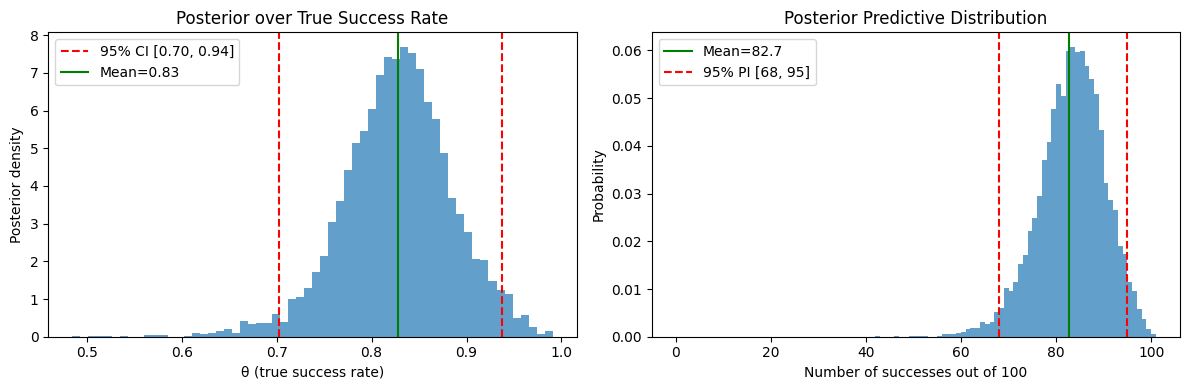


=== MCMC Diagnostics ===
        mean     sd  hdi_3%  hdi_97%  r_hat
theta  0.827  0.058   0.724    0.942    1.0
tpr    0.944  0.035   0.879    0.996    1.0
tnr    0.834  0.103   0.644    0.989    1.0


In [14]:
theta_samples = idata.posterior['theta'].values.flatten()

mean_est = theta_samples.mean()
ci_low, ci_high = np.percentile(theta_samples, [2.5, 97.5])
map_est = theta_samples[np.argmax(np.histogram(theta_samples, bins=100)[0])]  # approx MAP

print('=== Bayesian Results ===')
print(f'Posterior mean (θ)    : {mean_est:.3f} ({mean_est*100:.1f}%)')
print(f'95% Credible Interval : [{ci_low:.3f}, {ci_high:.3f}]')
print(f'P(θ > 0.80)           : {(theta_samples > 0.80).mean():.3f}')
print(f'P(θ > 0.90)           : {(theta_samples > 0.90).mean():.3f}')

# Posterior predictive
rng = np.random.default_rng(42)
pred_counts = rng.binomial(100, theta_samples)
pred_mean = pred_counts.mean()
pred_ci_low, pred_ci_high = np.percentile(pred_counts, [2.5, 97.5])

print(f'\n=== Posterior Predictive (out of 100 new traces) ===')
print(f'Expected successes : {pred_mean:.1f}')
print(f'95% Predictive CI  : [{pred_ci_low:.0f}, {pred_ci_high:.0f}]')
print(f'P(>80 successes)   : {(pred_counts > 80).mean():.3f}')
print(f'P(>90 successes)   : {(pred_counts > 90).mean():.3f}')

# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(theta_samples, bins=60, density=True, alpha=0.7)
axes[0].axvline(ci_low,   color='red',   linestyle='--', label=f'95% CI [{ci_low:.2f}, {ci_high:.2f}]')
axes[0].axvline(ci_high,  color='red',   linestyle='--')
axes[0].axvline(mean_est, color='green', linestyle='-',  label=f'Mean={mean_est:.2f}')
axes[0].set_xlabel('θ (true success rate)')
axes[0].set_ylabel('Posterior density')
axes[0].set_title('Posterior over True Success Rate')
axes[0].legend()

axes[1].hist(pred_counts, bins=range(0, 102), density=True, alpha=0.7)
axes[1].axvline(pred_mean,    color='green', linestyle='-',  label=f'Mean={pred_mean:.1f}')
axes[1].axvline(pred_ci_low,  color='red',   linestyle='--', label=f'95% PI [{pred_ci_low:.0f}, {pred_ci_high:.0f}]')
axes[1].axvline(pred_ci_high, color='red',   linestyle='--')
axes[1].set_xlabel('Number of successes out of 100')
axes[1].set_ylabel('Probability')
axes[1].set_title('Posterior Predictive Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

# MCMC diagnostics
print('\n=== MCMC Diagnostics ===')
print(az.summary(idata, var_names=['theta', 'tpr', 'tnr'])[['mean', 'sd', 'hdi_3%', 'hdi_97%', 'r_hat']])